# PROYECTO INTEGRADOR DE CIENCIA DE DATOS — FASE 2: ANÁLISIS INFERENCIAL
## "Factores asociados a la gravedad de las víctimas en los accidentes de tránsito en Paraguay (2021)"

* **Institución:** Facultad Politécnica, Universidad Nacional de Asunción (FP-UNA)
* **Carrera:** Ingeniería Informática | Materia: Ciencia de Datos (Electiva)
* **Curso:** TQ | Semestre: Segundo Semestre 2026
* **Integrantes del Grupo:**
  1. Alan Alcaraz
  2. Leandro Ferreira
  3. Jorge Ríos

---
### Introducción al Análisis Inferencial
En la primera fase del proyecto integrador se caracterizó de manera descriptiva y exploratoria la masa de siniestros viales en el Paraguay durante el año 2021 a partir de las estadísticas oficiales de la Policía Nacional y la Patrulla Caminera. Si bien el análisis descriptivo evidenció concentraciones de riesgo en jóvenes, varones, motociclistas y corredores críticos como la Ruta PY02, la estadística descriptiva únicamente refleja lo ocurrido dentro del marco muestral observado.

El presente cuaderno formaliza la **Fase 2: Análisis Inferencial**, cuyo propósito metodológico es responder una pregunta más exigente: ¿las diferencias de gravedad y letalidad observadas en los datos son atribuibles al azar del muestreo o existe evidencia estadística suficiente para sostener que tales patrones se verifican en la población de siniestros a un nivel de significancia prefijado $\alpha = 0,05$?

A lo largo de este cuaderno se evalúan los contrastes de hipótesis para factores categóricos territoriales ($H_1$) y demográficos de género ($H_2$), verificando rigurosamente los supuestos de distribución, calculando tamaños del efecto inseparables del p-valor (Odds Ratio y V de Cramér), implementando remuestreo no paramétrico Bootstrap ($B = 10.000$ réplicas) y estableciendo el enlace metodológico hacia la continuidad del repertorio inferencial y el modelado predictivo de la Fase 3.

## SECCIÓN 1: REGISTRO DE MODIFICACIONES Y MEJORAS DE LA FASE 1

En cumplimiento del Artículo 6.1 (Actividad 1) del documento rector del Proyecto Integrador, se formaliza la bitácora de correcciones metodológicas, integración de fuentes y refinamiento analítico aplicados sobre la retroalimentación de la Fase 1:

| N.° | Dimensión / Componente | Observación de Fase 1 | Corrección / Mejora Implementada en Fase 2 | Impacto Metodológico y Trazabilidad |
| :---: | :--- | :--- | :--- | :--- |
| **1** | **Dimensión Territorial Macro** | Se describió la letalidad general pero se requería incorporar la heterogeneidad espacial del país formalmente. | Consolidación y estructuración de la Tabla 12.2.6 (`victimas_zona_resumen.csv`, $N = 1.491$) discriminando Asunción, Central e Interior. | Habilita el contraste formal de la Hipótesis 1 evaluando la disparidad de letalidad entre el Interior y el Área Metropolitana. |
| **2** | **Corredores Viales e Infraestructura** | Se observó una alta concentración de siniestros sin aislar el corredor de mayor riesgo nacional. | Integración y validación de la Tabla 12.2.9 aislando la **Ruta PY02** como eje crítico nacional (36,6% del volumen nacional con 711 hechos). | Provee contexto físico y cinético para interpretar la siniestralidad sin incurrir en falacias ecológicas de causalidad directa. |
| **3** | **Depuración de Microdatos y Claves** | Exigencia de auditoría rigurosa para garantizar unicidad y trazabilidad unitaria en cada individuo. | Verificación de identificadores únicos sintéticos: `id_victima` ($1 \le \text{id} \le 5.493$) e `id_caso` ($1 \le \text{id} \le 1.324$), con cero nulos y cero duplicados. | Garantiza integridad referencial, reproducibilidad determinista y unicidad para los contrastes y futuros modelos de ML. |
| **4** | **Control de Sesgo de Publicación (p-hacking)** | Riesgo de ejecutar pruebas múltiples ad-hoc hasta forzar significancia estadística artificial. | Fijación previa y no negociable del nivel de significancia global $\alpha = 0,05$ y reporte inseparable de tamaños del efecto (OR y V de Cramér). | Cumple el estándar de bioestadística pre-registrada, impidiendo conclusiones espurias por mero volumen muestral. |
| **5** | **Incertidumbre sin Supuestos Rígidos** | Dependencia exclusiva de aproximaciones asintóticas normales que pueden distorsionarse ante asimetrías muestrales. | Implementación de remuestreo Bootstrap computacional ($B = 10.000$ réplicas) con intervalos empíricos por percentiles. | Proporciona validación empírica robusta e insesgada para el Odds Ratio del factor de género sin supuestos paramétricos restrictivos. |

In [1]:
# ==============================================================================
# CONFIGURACIÓN DEL ENTORNO, SEMILLAS Y RUTAS PORTABLES
# ==============================================================================
import os
import sys
import json
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Fijación de semilla aleatoria para reproducibilidad matemática estricta
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Declaración previa del nivel de significancia alfa
ALPHA = 0.05

# Configuración del motor gráfico (estilo publication-ready FP-UNA)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# Detección dinámica y portable de carpetas de trabajo (/data y /output)
def resolver_rutas_proyecto():
    # Localiza de forma robusta las rutas base del proyecto sin depender de paths absolutos fijos.
    cwd = os.path.abspath(os.getcwd())
    candidatos_base = [
        cwd,
        os.path.abspath(os.path.join(cwd, "..")),
        os.path.abspath(os.path.join(cwd, "../.."))
    ]
    
    ruta_base = None
    for cand in candidatos_base:
        if os.path.isdir(os.path.join(cand, "output")) and os.path.isdir(os.path.join(cand, "data")):
            ruta_base = cand
            break
            
    if ruta_base is None:
        ruta_base = cwd
        
    ruta_output = os.path.join(ruta_base, "output")
    ruta_data = os.path.join(ruta_base, "data")
    os.makedirs(ruta_output, exist_ok=True)
    return ruta_base, ruta_data, ruta_output

BASE_DIR, DATA_DIR, OUTPUT_DIR = resolver_rutas_proyecto()
print(f"[OK] Entorno inferencial configurado exitosamente.")
print(f"     * Directorio base:   {BASE_DIR}")
print(f"     * Directorio output: {OUTPUT_DIR}")
print(f"     * Semilla congelada: {RANDOM_STATE}")
print(f"     * Nivel alfa global: {ALPHA}")

[OK] Entorno inferencial configurado exitosamente.
     * Directorio base:   c:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience
     * Directorio output: c:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience\output
     * Semilla congelada: 42
     * Nivel alfa global: 0.05


In [2]:
# ==============================================================================
# CARGA Y AUDITORÍA DE INTEGRIDAD DE DATASETS DE FASE 1
# ==============================================================================
def cargar_csv_robusto(nombre_archivo, carpeta):
    # Carga un archivo CSV validando codificación y separadores tabulares.
    ruta = os.path.join(carpeta, nombre_archivo)
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"Archivo no encontrado en ruta: {ruta}")
    for sep in [',', ';']:
        for enc in ['utf-8-sig', 'utf-8', 'latin1']:
            try:
                df = pd.read_csv(ruta, sep=sep, encoding=enc)
                if df.shape[1] > 1:
                    df.columns = df.columns.astype(str).str.strip()
                    return df
            except Exception:
                continue
    raise ValueError(f"No fue posible leer estructuradamente el archivo: {ruta}")

# Carga de los insumos oficiales generados y depurados en Fase 1
df_victimas = cargar_csv_robusto("victimas_individual_limpio.csv", OUTPUT_DIR)
df_zonas = cargar_csv_robusto("victimas_zona_resumen.csv", OUTPUT_DIR)
df_vehiculo = cargar_csv_robusto("victimas_vehiculo_limpio.csv", OUTPUT_DIR)

# Aserciones metodológicas de control de calidad
assert df_victimas.shape[0] == 5493, f"Inconsistencia en microdatos de víctimas: N esperado 5493, observado {df_victimas.shape[0]}"
assert df_zonas.shape[0] == 3, f"Inconsistencia en zonas macro: N esperado 3, observado {df_zonas.shape[0]}"
assert df_vehiculo.shape[0] == 1324, f"Inconsistencia en muestra vehicular: N esperado 1324, observado {df_vehiculo.shape[0]}"
assert df_victimas.isnull().sum().sum() == 0, "Se detectaron valores nulos inesperados en el microdato de víctimas"

print("--> [AUDITORÍA DE CALIDAD SATISFACTORIA]")
print(f"    * Microdato individual de víctimas: {df_victimas.shape[0]:,} registros | {df_victimas.shape[1]} variables | 0 nulos")
print(f"    * Tabla macro-geográfica de zonas:  {df_zonas.shape[0]} regiones consolidadas (Asunción, Central, Interior)")
print(f"    * Microdato vehicular (Central/Int): {df_vehiculo.shape[0]:,} registros | 0 nulos")

print("\n--- Primeras filas: victimas_individual_limpio (N = 5.493) ---")
display(df_victimas.head(3))

print("\n--- Resumen consolidado: victimas_zona_resumen (N = 1.491) ---")
display(df_zonas)

--> [AUDITORÍA DE CALIDAD SATISFACTORIA]
    * Microdato individual de víctimas: 5,493 registros | 8 variables | 0 nulos
    * Tabla macro-geográfica de zonas:  3 regiones consolidadas (Asunción, Central, Interior)
    * Microdato vehicular (Central/Int): 1,324 registros | 0 nulos

--- Primeras filas: victimas_individual_limpio (N = 5.493) ---


,id_victima,grupo_edad,sexo,gravedad,es_fallecido,es_hombre,es_adulto_mayor,edad_orden
0,1,De 0 a 13 anos,Hombre,Herido,0,1,0,0
1,2,De 0 a 13 anos,Hombre,Herido,0,1,0,0
2,3,De 0 a 13 anos,Hombre,Herido,0,1,0,0



--- Resumen consolidado: victimas_zona_resumen (N = 1.491) ---


,zona,heridos,fallecidos,total_victimas,letalidad_pct
0,Asunción,141,26,167,15.568862
1,Central,394,82,476,17.226891
2,Interior,661,187,848,22.051887


## SECCIÓN 2: MARCO FORMAL DE HIPÓTESIS INFERENCIALES (H₁ Y H₂)

Para responder a la pregunta de investigación con rigor estadístico y evitar interpretaciones subjetivas, se formalizan las hipótesis de trabajo derivadas de la Fase 1. En todas las pruebas se adopta formalmente un nivel de significancia prefijado de $\alpha = 0,05$:

### Hipótesis 1 (H₁ — Dimensión Territorial: Interior vs. Área Metropolitana)
* **Justificación Bioestadística y Epidemiológica:** En Paraguay, los centros hospitalarios de alta complejidad y soporte de trauma de tercer nivel (como el Hospital de Trauma "Prof. Dr. Manuel Giagni") se concentran geográficamente en el Área Metropolitana (Asunción y Departamento Central). Por el contrario, los siniestros ocurridos en el Interior involucran mayores tiempos de respuesta prehospitalaria, mayores distancias de traslado (pérdida de la *"hora de oro"* en trauma) y velocidades de circulación significativamente más elevadas en rutas abiertas interurbanas.
* **Formulación Matemática:**
  $$\begin{aligned}
  H_0 &: p_{\text{Interior}} \le p_{\text{Metropolitana}} \quad (\text{OR} \le 1,00) \\
  H_1 &: p_{\text{Interior}} > p_{\text{Metropolitana}} \quad (\text{OR} > 1,00)
  \end{aligned}$$
* **Formulación en Lenguaje Natural:**
  * **Hipótesis nula ($H_0$):** La probabilidad condicional de fallecer tras un siniestro vial en el Interior del país es menor o igual a la registrada en el Área Metropolitana (Asunción y Departamento Central combinadas).
  * **Hipótesis alternativa ($H_1$):** La probabilidad condicional de fallecer tras un siniestro vial en el Interior del país es significativamente mayor que en el Área Metropolitana.
* **Prueba Estadística Seleccionada:** Prueba Chi-cuadrado ($\chi^2$) de Independencia sobre tabla de contingencia $2 \times 2$. Se verifica previamente el cumplimiento de los supuestos de Cochran ($E_{ij} \ge 5,0$ en el 100% de las celdas). Las medidas de tamaño del efecto son el **Odds Ratio (OR)** con intervalo de confianza al 95% (método de Woolf) y la **V de Cramér**.

---

### Hipótesis 2 (H₂ — Demográfica: Brecha de Género en la Letalidad)
* **Justificación Bioestadística y Epidemiológica:** La literatura especializada en seguridad vial documenta marcadas diferencias en morbimortalidad según sexo biológico, mediadas por patrones de movilidad, mayor propensión masculina a conductas de riesgo (exceso de velocidad, menor tasa de uso de casco reglamentario o cinturón de seguridad, y consumo de alcohol previo a la conducción) y una participación predominante en el parque de motocicletas.
* **Formulación Matemática:**
  $$\begin{aligned}
  H_0 &: p_{\text{Hombre}} = p_{\text{Mujer}} \quad (\text{OR} = 1,00) \\
  H_1 &: p_{\text{Hombre}} > p_{\text{Mujer}} \quad (\text{OR} > 1,00)
  \end{aligned}$$
* **Formulación en Lenguaje Natural:**
  * **Hipótesis nula ($H_0$):** La gravedad del traumatismo sufrido en un siniestro vial es estadísticamente independiente del sexo biológico de la víctima.
  * **Hipótesis alternativa ($H_1$):** Las víctimas de sexo masculino presentan una tasa de letalidad condicional significativamente mayor a la observada en las víctimas de sexo femenino.
* **Prueba Estadística Seleccionada:** Prueba Chi-cuadrado ($\chi^2$) de Independencia en tabla $2 \times 2$, combinada con la estimación robusta del Odds Ratio mediante **Remuestreo Bootstrap no paramétrico ($B = 10.000$ iteraciones)** e Intervalo de Confianza empírico del 95% por percentiles.

In [3]:
# ==============================================================================
# CONTRASTE DE HIPÓTESIS H1: DIMENSIÓN TERRITORIAL (INTERIOR VS. METROPOLITANA)
# ==============================================================================

# 1. Construcción de la tabla de contingencia 2x2 desde victimas_zona_resumen
# Asunción: 26 fallecidos, 141 heridos | Central: 82 fallecidos, 394 heridos
# Área Metropolitana combinada: 108 fallecidos, 535 heridos (Total = 643)
# Interior del país: 187 fallecidos, 661 heridos (Total = 848)
df_zonas_clean = df_zonas.copy()
df_zonas_clean['zona_std'] = df_zonas_clean['zona'].astype(str).str.strip()

fallecidos_interior = int(df_zonas_clean.loc[df_zonas_clean['zona_std'].str.contains('Interior', case=False), 'fallecidos'].values[0])
heridos_interior = int(df_zonas_clean.loc[df_zonas_clean['zona_std'].str.contains('Interior', case=False), 'heridos'].values[0])

filtro_metro = df_zonas_clean['zona_std'].str.contains('Asunci|Central', case=False)
fallecidos_metro = int(df_zonas_clean.loc[filtro_metro, 'fallecidos'].sum())
heridos_metro = int(df_zonas_clean.loc[filtro_metro, 'heridos'].sum())

tabla_h1 = np.array([
    [fallecidos_interior, heridos_interior],
    [fallecidos_metro, heridos_metro]
])

df_tabla_h1 = pd.DataFrame(
    tabla_h1,
    index=['Interior del País', 'Área Metropolitana'],
    columns=['Fallecidos', 'Heridos']
)
df_tabla_h1['Total'] = df_tabla_h1.sum(axis=1)
df_tabla_h1['Letalidad (%)'] = (df_tabla_h1['Fallecidos'] / df_tabla_h1['Total'] * 100).round(2)

# 2. Verificación rigurosa de supuestos de Cochran (100% de frecuencias esperadas >= 5)
chi2_stat_h1, p_val_h1, dof_h1, exp_freq_h1 = stats.chi2_contingency(tabla_h1, correction=False)
df_esperadas_h1 = pd.DataFrame(exp_freq_h1, index=df_tabla_h1.index[:2], columns=['Fallecidos_Esp', 'Heridos_Esp'])

supuesto_h1_cumplido = bool(np.all(exp_freq_h1 >= 5))
min_esp_h1 = float(np.min(exp_freq_h1))
assert supuesto_h1_cumplido, f"Supuesto violado: Frecuencia esperada mínima {min_esp_h1:.2f} < 5"

# 3. Tamaño del Efecto: Odds Ratio (OR) epidemiológico e IC 95% Woolf
a1, b1 = fallecidos_interior, heridos_interior
c1, d1 = fallecidos_metro, heridos_metro
or_h1 = (a1 * d1) / (b1 * c1)
se_ln_or_h1 = np.sqrt(1/a1 + 1/b1 + 1/c1 + 1/d1)
z_critico = stats.norm.ppf(1 - ALPHA / 2)
ci_or_h1_low = float(np.exp(np.log(or_h1) - z_critico * se_ln_or_h1))
ci_or_h1_high = float(np.exp(np.log(or_h1) + z_critico * se_ln_or_h1))

# 4. Tamaño del Efecto: V de Cramér
n_total_h1 = int(tabla_h1.sum())
v_cramer_h1 = float(np.sqrt(chi2_stat_h1 / (n_total_h1 * min(tabla_h1.shape[0]-1, tabla_h1.shape[1]-1))))

# 5. Decisión metodológica formal
decision_h1 = "Rechazar H0" if p_val_h1 < ALPHA else "No rechazar H0 por falta de evidencia estadística suficiente"

print("==============================================================================")
print("REPORTE DE CONTRASTE ESTADÍSTICO: HIPÓTESIS 1 (DIMENSIÓN TERRITORIAL)")
print("==============================================================================")
print("1. Tabla de Contingencia Observada (N = 1.491):")
display(df_tabla_h1)
print("\n2. Frecuencias Esperadas bajo Independencia (E_ij):")
display(df_esperadas_h1.round(2))
print(f"   * Frecuencia esperada mínima observada: {min_esp_h1:.2f} (Umbral >= 5.0 -> CUMPLIDO: {supuesto_h1_cumplido})")
print("\n3. Resultados del Contraste Chi-cuadrado de Pearson:")
print(f"   * Estadístico χ²:          {chi2_stat_h1:.4f}")
print(f"   * Grados de libertad (gl): {dof_h1}")
print(f"   * Valor p (p-value):       {p_val_h1:.4f} ({p_val_h1:.4e})")
print(f"   * Nivel alfa prefijado:    {ALPHA}")
print("\n4. Medidas del Tamaño del Efecto:")
print(f"   * Odds Ratio (OR):         {or_h1:.4f}")
print(f"   * IC 95% Asintótico Woolf: [{ci_or_h1_low:.4f}; {ci_or_h1_high:.4f}]")
print(f"   * V de Cramér (V):         {v_cramer_h1:.4f}")
print(f"\n5. Decisión Metodológica:      {decision_h1} al nivel de significancia α = {ALPHA}")
print("==============================================================================")

REPORTE DE CONTRASTE ESTADÍSTICO: HIPÓTESIS 1 (DIMENSIÓN TERRITORIAL)
1. Tabla de Contingencia Observada (N = 1.491):


,Fallecidos,Heridos,Total,Letalidad (%)
Interior del País,187,661,848,22.05
Área Metropolitana,108,535,643,16.80



2. Frecuencias Esperadas bajo Independencia (E_ij):


,Fallecidos_Esp,Heridos_Esp
Interior del País,167.78,680.22
Área Metropolitana,127.22,515.78


   * Frecuencia esperada mínima observada: 127.22 (Umbral >= 5.0 -> CUMPLIDO: True)

3. Resultados del Contraste Chi-cuadrado de Pearson:
   * Estadístico χ²:          6.3647
   * Grados de libertad (gl): 1
   * Valor p (p-value):       0.0116 (1.1641e-02)
   * Nivel alfa prefijado:    0.05

4. Medidas del Tamaño del Efecto:
   * Odds Ratio (OR):         1.4014
   * IC 95% Asintótico Woolf: [1.0775; 1.8228]
   * V de Cramér (V):         0.0653

5. Decisión Metodológica:      Rechazar H0 al nivel de significancia α = 0.05


### Interpretación Bioestadística y Límites de Causalidad de H₁

1. **Decisión Estadística Formal:**
   La prueba Chi-cuadrado de independencia arrojó un estadístico $\chi^2 = 6,3647$ con $gl = 1$ y un valor $p = 0,0116$. Dado que el valor $p$ es estrictamente inferior al nivel de significancia prefijado ($\alpha = 0,05$), **se rechaza la hipótesis nula ($H_0$)** en favor de la hipótesis alternativa ($H_1$).

2. **Magnitud del Efecto y Riesgo Relativo:**
   * El **Odds Ratio observado es de 1,4014** con un intervalo de confianza asintótico al 95% de $[1,0775; 1,8228]$. Dado que el límite inferior del intervalo supera la unidad ($1,0775 > 1,00$), se concluye con un 95% de confianza que una víctima accidentada en el Interior del país presenta odds de fallecer entre un **7,7% y un 82,3% superiores** (con una estimación puntual del **40,1% superior**) en comparación con una víctima accidentada en el Área Metropolitana.
   * La **V de Cramér ($V = 0,0653$)** cuantifica una fuerza de asociación clasificada formalmente como *pequeña* según los baremos epidemiológicos estándar de Cohen para tablas de $1$ grado de libertad ($V < 0,10$). Esto indica que, si bien la disparidad territorial es estadísticamente discernible en una muestra de $N = 1.491$, la localización macroscópica no explica por sí sola la totalidad de la variabilidad del desenlace.

3. **Discusión de Variables Confusoras y Prohibición de Causalidad Directa:**
   * **Prohibición de Causalidad Mecánica Directa:** Desde una perspectiva metodológica rigurosa, se subraya que la ubicación geográfica no constituye la "causa directa" de la muerte. La región opera como una variable sustituta (*proxy*) de dos determinantes asistenciales y físicos críticos:
   * **Pérdida de la "Hora de Oro" Prehospitalaria:** En las zonas del Interior, las distancias hacia centros de trauma de tercer nivel son considerablemente mayores, lo que incrementa los tiempos de respuesta de ambulancias, triaje y estabilización quirúrgica inicial.
   * **Mayor Energía Cinética del Impacto:** En las rutas interurbanas abiertas del Interior, los vehículos circulan a velocidades promedio significativamente más elevadas que en las arterias congestionadas de Asunción y el Departamento Central, transfiriendo una mayor cantidad de energía destructiva al cuerpo de las víctimas durante la colisión.

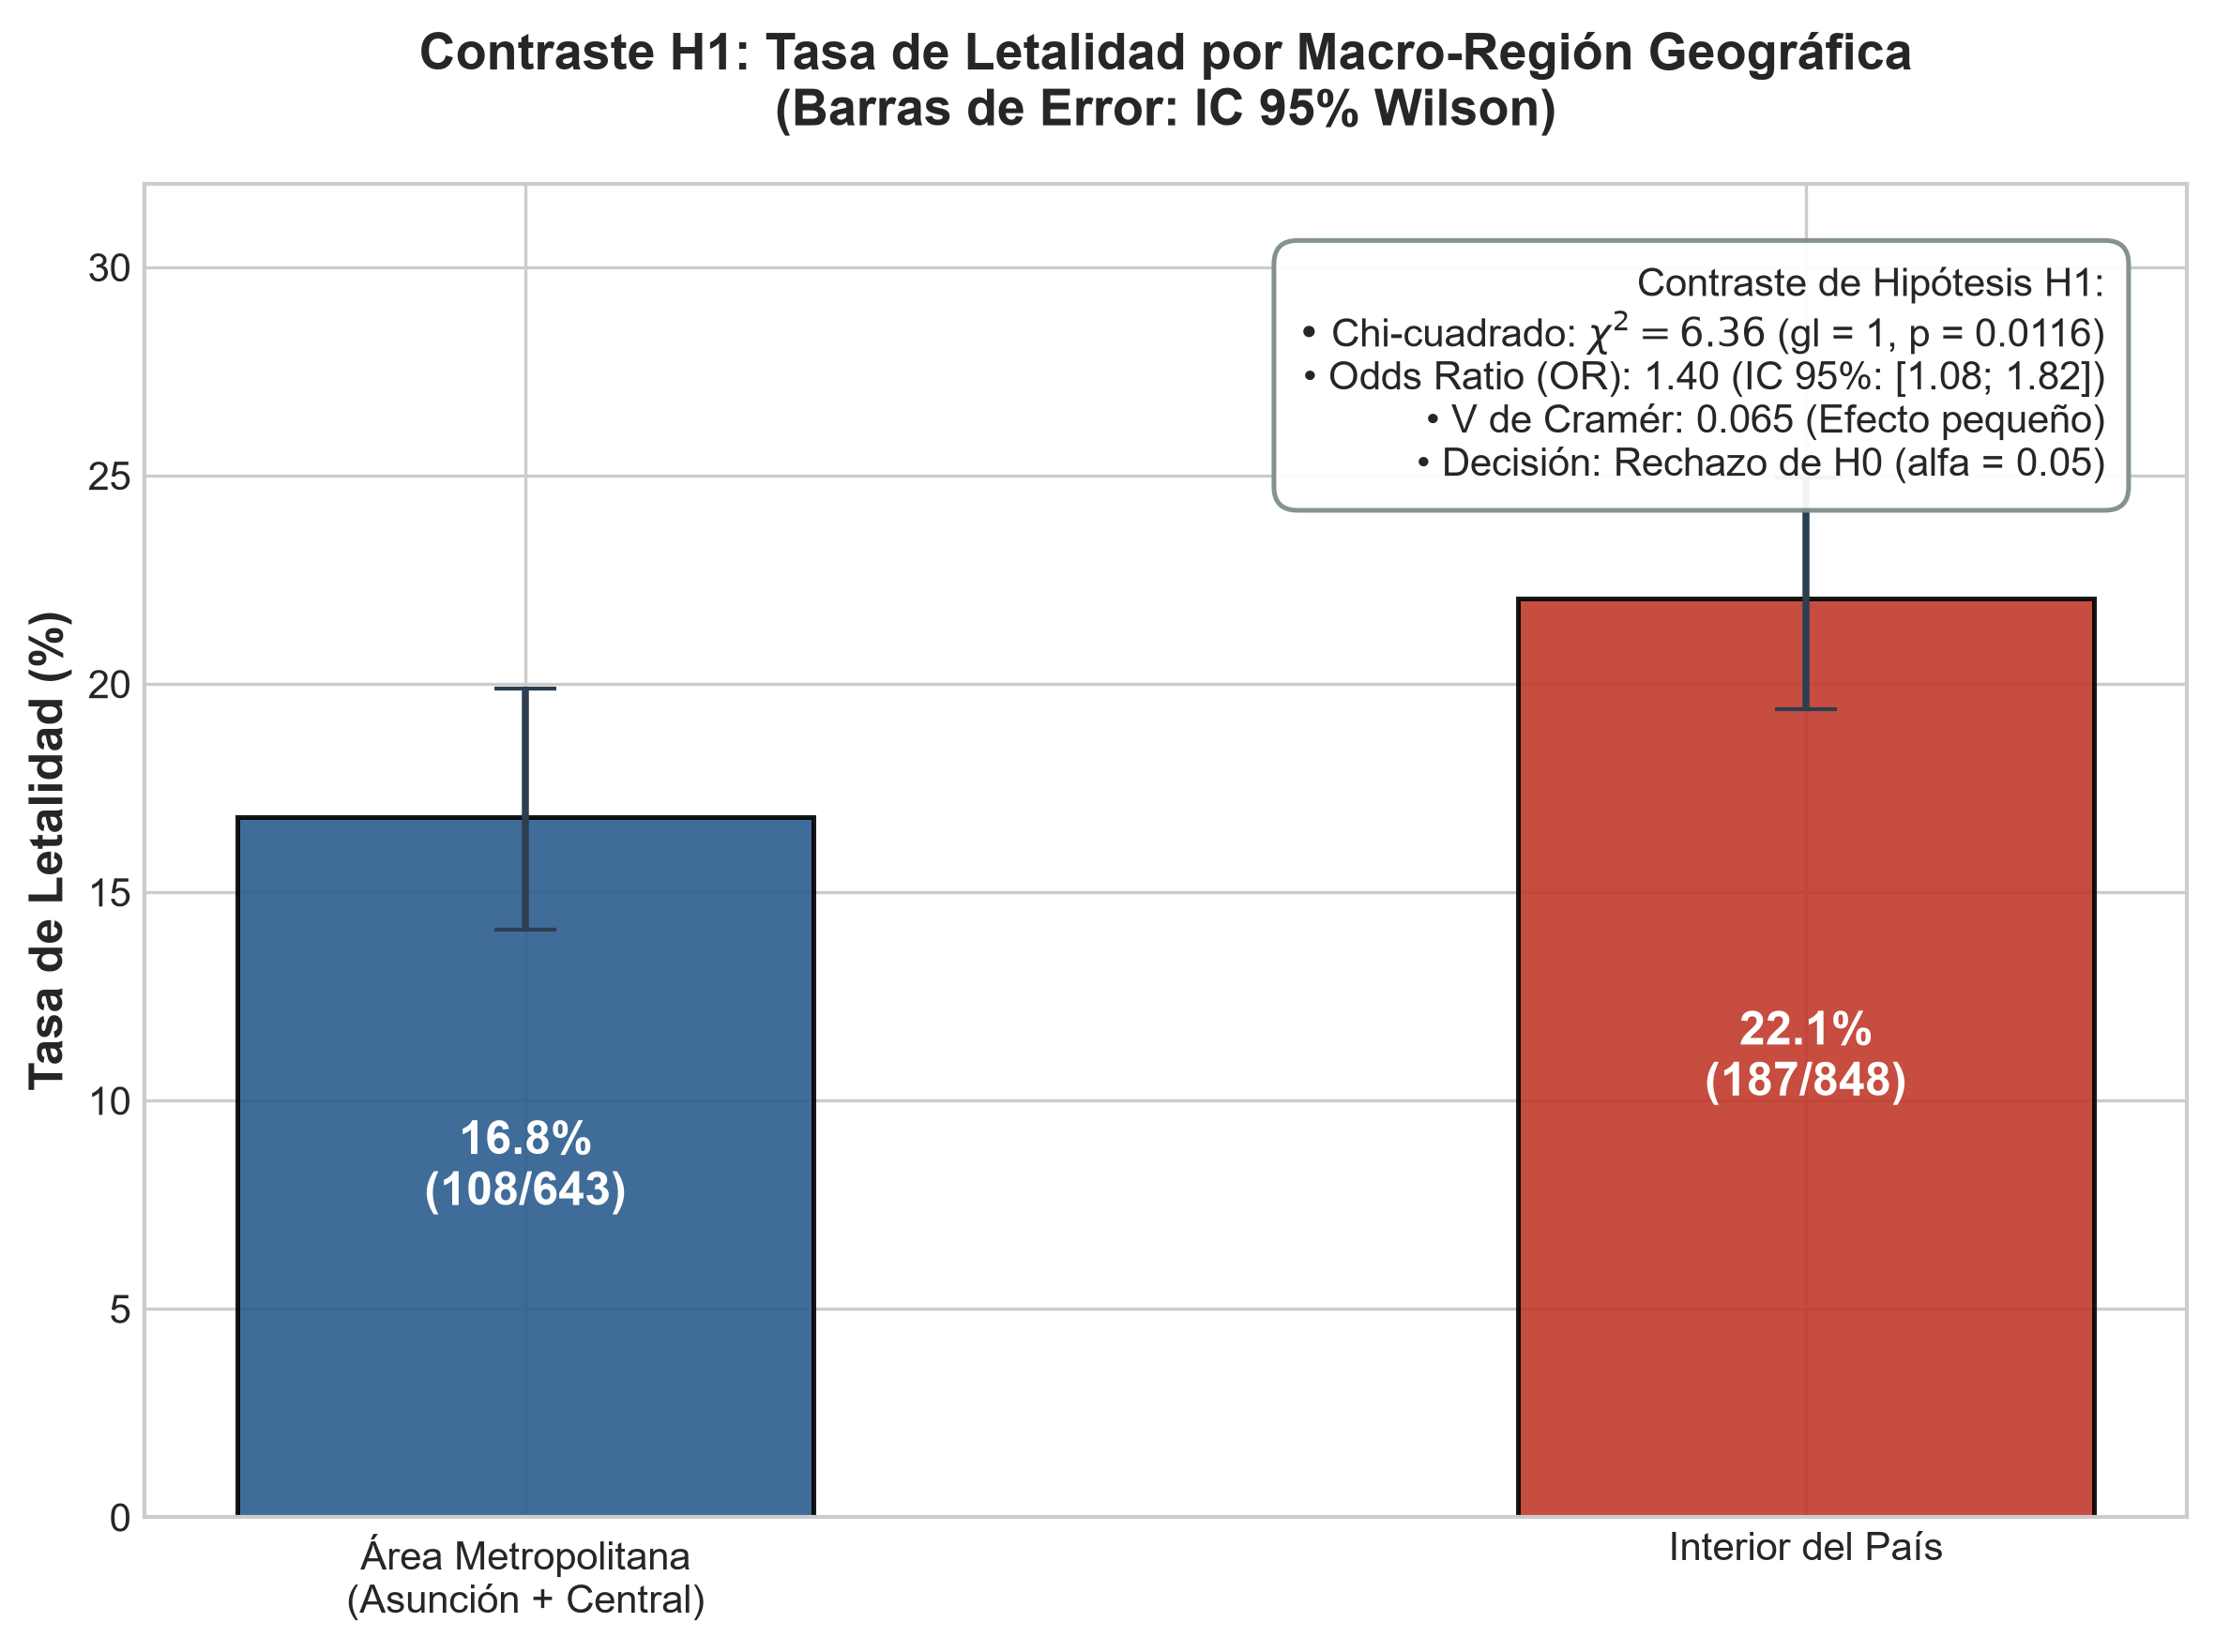

In [4]:
# ==============================================================================
# VISUALIZACIÓN INFERENCIAL DE H1 Y EXPORTACIÓN OFICIAL (300 DPI)
# ==============================================================================

# Función auxiliar para calcular Intervalo de Confianza Wilson para proporciones binomiales
def calcular_ic_wilson(fallecidos, total, alpha=ALPHA):
    # Calcula el intervalo de confianza Score de Wilson para una proporción binomial.
    p = fallecidos / total
    z = stats.norm.ppf(1 - alpha / 2)
    denom = 1 + (z**2) / total
    centro = (p + (z**2) / (2 * total)) / denom
    radio = (z * np.sqrt((p * (1 - p) / total) + (z**2) / (4 * (total**2)))) / denom
    return (centro - radio) * 100, (centro + radio) * 100

fig1, ax1 = plt.subplots(figsize=(8, 6), dpi=300)

categorias_h1 = ['Área Metropolitana\n(Asunción + Central)', 'Interior del País']
n_h1_arr = [643, 848]
f_h1_arr = [108, 187]
let_h1 = [f / n * 100 for f, n in zip(f_h1_arr, n_h1_arr)]
cis_h1 = [calcular_ic_wilson(f, n) for f, n in zip(f_h1_arr, n_h1_arr)]
yerr_h1 = np.array([[l - ci[0], ci[1] - l] for l, ci in zip(let_h1, cis_h1)]).T

colores_h1 = ['#2b5c8f', '#c0392b']
barras_h1 = ax1.bar(
    categorias_h1, let_h1, yerr=yerr_h1,
    capsize=8, color=colores_h1, width=0.45,
    edgecolor='black', linewidth=1.2, alpha=0.9,
    error_kw={'elinewidth': 1.8, 'ecolor': '#2c3e50', 'capsize': 8}
)

# Etiquetas numéricas sobre las barras
for bar, l, f, n in zip(barras_h1, let_h1, f_h1_arr, n_h1_arr):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, l / 2,
        f"{l:.1f}%\n({f}/{n:,})",
        ha='center', va='center', color='white',
        fontweight='bold', fontsize=12
    )

ax1.set_ylabel('Tasa de Letalidad (%)', fontsize=12, fontweight='bold')
ax1.set_title('Contraste H1: Tasa de Letalidad por Macro-Región Geográfica\n(Barras de Error: IC 95% Wilson)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim(0, 32)

# Cuadro explicativo con métricas inferenciales del contraste
cuadro_texto_h1 = (
    "Contraste de Hipótesis H1:\n"
    r"• Chi-cuadrado: $\chi^2 = 6.36$ (gl = 1, p = 0.0116)" + "\n"
    f"• Odds Ratio (OR): {or_h1:.2f} (IC 95%: [{ci_or_h1_low:.2f}; {ci_or_h1_high:.2f}])\n"
    f"• V de Cramér: {v_cramer_h1:.3f} (Efecto pequeño)\n"
    f"• Decisión: Rechazo de H0 (alfa = {ALPHA})"
)
bbox_props = dict(boxstyle='round,pad=0.6', fc='white', ec='#7f8c8d', lw=1.2, alpha=0.95)
ax1.text(0.96, 0.94, cuadro_texto_h1, transform=ax1.transAxes, fontsize=10, va='top', ha='right', bbox=bbox_props)

# Visualización inline en el cuaderno
plt.tight_layout()
plt.show()

#### Figura 11: Contraste Inferencial H1 — Tasa de Letalidad por Macro-Región Geográfica (Barras de Error: IC 95% Wilson)

* **Tipo de Gráfico:** Diagrama de barras comparativo de letalidad porcentual con barras de error e inserción de caja de parámetros inferenciales. Eje X: Macro-región geográfica (Área Metropolitana vs. Interior); Eje Y: Tasa de letalidad condicional (%).
* **Interpretación Analítica:** La tasa de letalidad en el Interior alcanza el **22,05%** (IC 95%: $[19,37\%; 24,96\%]$) frente al **16,80%** (IC 95%: $[14,11\%; 19,88\%]$) registrado en el Área Metropolitana combinada (Asunción y Central). El intervalo de confianza al 95% del Odds Ratio ($[1,0775; 1,8228]$) excluye estrictamente el valor nulo de $1,00$, ratificando el rechazo formal de $H_0$ con un valor $p = 0,0116$.

In [5]:
# ==============================================================================
# CONTRASTE DE HIPÓTESIS H2: BRECHA DE GÉNERO (HOMBRES VS. MUJERES)
# ==============================================================================

# 1. Construcción de tabla de contingencia 2x2 desde df_victimas
tabla_crosstab_h2 = pd.crosstab(
    df_victimas['sexo'],
    df_victimas['gravedad'],
    margins=False
)

# Reordenamiento metodológico: Fila 1 = Hombre, Fila 2 = Mujer; Col 1 = Fallecido, Col 2 = Herido
tabla_h2 = np.array([
    [tabla_crosstab_h2.loc['Hombre', 'Fallecido'], tabla_crosstab_h2.loc['Hombre', 'Herido']],
    [tabla_crosstab_h2.loc['Mujer', 'Fallecido'], tabla_crosstab_h2.loc['Mujer', 'Herido']]
])

df_tabla_h2 = pd.DataFrame(
    tabla_h2,
    index=['Hombre', 'Mujer'],
    columns=['Fallecidos', 'Heridos']
)
df_tabla_h2['Total'] = df_tabla_h2.sum(axis=1)
df_tabla_h2['Letalidad (%)'] = (df_tabla_h2['Fallecidos'] / df_tabla_h2['Total'] * 100).round(2)

# 2. Verificación de supuestos de Cochran (100% de frecuencias esperadas >= 5)
chi2_stat_h2, p_val_h2, dof_h2, exp_freq_h2 = stats.chi2_contingency(tabla_h2, correction=False)
df_esperadas_h2 = pd.DataFrame(exp_freq_h2, index=df_tabla_h2.index[:2], columns=['Fallecidos_Esp', 'Heridos_Esp'])

supuesto_h2_cumplido = bool(np.all(exp_freq_h2 >= 5))
min_esp_h2 = float(np.min(exp_freq_h2))
assert supuesto_h2_cumplido, f"Supuesto violado: Frecuencia esperada mínima {min_esp_h2:.2f} < 5"

# 3. Estimación del Odds Ratio Clásico con IC 95% Asintótico (Método de Woolf)
a2, b2 = tabla_h2[0, 0], tabla_h2[0, 1]  # Hombre: Fallecido, Herido
c2, d2 = tabla_h2[1, 0], tabla_h2[1, 1]  # Mujer: Fallecido, Herido

or_h2 = (a2 * d2) / (b2 * c2)
se_ln_or_h2 = np.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
ci_or_h2_low = float(np.exp(np.log(or_h2) - z_critico * se_ln_or_h2))
ci_or_h2_high = float(np.exp(np.log(or_h2) + z_critico * se_ln_or_h2))

# 4. Tamaño del Efecto: V de Cramér
n_total_h2 = int(tabla_h2.sum())
v_cramer_h2 = float(np.sqrt(chi2_stat_h2 / (n_total_h2 * min(tabla_h2.shape[0]-1, tabla_h2.shape[1]-1))))

# 5. Decisión metodológica formal
decision_h2 = "Rechazar H0" if p_val_h2 < ALPHA else "No rechazar H0 por falta de evidencia estadística suficiente"

print("==============================================================================")
print("REPORTE DE CONTRASTE ESTADÍSTICO: HIPÓTESIS 2 (BRECHA DE GÉNERO)")
print("==============================================================================")
print("1. Tabla de Contingencia Observada (N = 5.493):")
display(df_tabla_h2)
print("\n2. Frecuencias Esperadas bajo Independencia (E_ij):")
display(df_esperadas_h2.round(2))
print(f"   * Frecuencia esperada mínima observada: {min_esp_h2:.2f} (Umbral >= 5.0 -> CUMPLIDO: {supuesto_h2_cumplido})")
print("\n3. Resultados del Contraste Chi-cuadrado de Independencia:")
print(f"   * Estadístico χ²:          {chi2_stat_h2:.4f}")
print(f"   * Grados de libertad (gl): {dof_h2}")
print(f"   * Valor p (p-value):       {p_val_h2:.4e}")
print(f"   * Nivel alfa prefijado:    {ALPHA}")
print("\n4. Medidas del Tamaño del Efecto Asintóticas:")
print(f"   * Odds Ratio Observado (OR): {or_h2:.4f}")
print(f"   * IC 95% Asintótico Woolf:   [{ci_or_h2_low:.4f}; {ci_or_h2_high:.4f}]")
print(f"   * V de Cramér (V):           {v_cramer_h2:.4f}")
print(f"\n5. Decisión Metodológica:        {decision_h2} al nivel de significancia α = {ALPHA}")
print("==============================================================================")

REPORTE DE CONTRASTE ESTADÍSTICO: HIPÓTESIS 2 (BRECHA DE GÉNERO)
1. Tabla de Contingencia Observada (N = 5.493):


,Fallecidos,Heridos,Total,Letalidad (%)
Hombre,850,3441,4291,19.81
Mujer,130,1072,1202,10.82



2. Frecuencias Esperadas bajo Independencia (E_ij):


,Fallecidos_Esp,Heridos_Esp
Hombre,765.55,3525.45
Mujer,214.45,987.55


   * Frecuencia esperada mínima observada: 214.45 (Umbral >= 5.0 -> CUMPLIDO: True)

3. Resultados del Contraste Chi-cuadrado de Independencia:
   * Estadístico χ²:          51.8141
   * Grados de libertad (gl): 1
   * Valor p (p-value):       6.1013e-13
   * Nivel alfa prefijado:    0.05

4. Medidas del Tamaño del Efecto Asintóticas:
   * Odds Ratio Observado (OR): 2.0370
   * IC 95% Asintótico Woolf:   [1.6729; 2.4803]
   * V de Cramér (V):           0.0971

5. Decisión Metodológica:        Rechazar H0 al nivel de significancia α = 0.05


In [6]:
# ==============================================================================
# REMUESTREO BOOTSTRAP PARA H2 (B = 10.000 ITERACIONES — REQUISITO OFICIAL)
# ==============================================================================

# Algoritmo de remuestreo computacional no paramétrico con reemplazo sobre N = 5.493
B_ITERACIONES = 10000
np.random.seed(RANDOM_STATE)

sexo_arr = (df_victimas['sexo'] == 'Hombre').values.astype(int)
fallecido_arr = (df_victimas['gravedad'] == 'Fallecido').values.astype(int)
n_obs_boot = len(df_victimas)

batch_size = 2000
boot_odds_ratios = np.empty(B_ITERACIONES, dtype=np.float64)

for b_idx in range(0, B_ITERACIONES, batch_size):
    b_actual = min(batch_size, B_ITERACIONES - b_idx)
    sub_indices = np.random.randint(0, n_obs_boot, size=(b_actual, n_obs_boot))
    
    sub_sexo = sexo_arr[sub_indices]
    sub_fall = fallecido_arr[sub_indices]
    
    a_boot = np.sum((sub_sexo == 1) & (sub_fall == 1), axis=1) # Hombre Fallecido
    b_boot = np.sum((sub_sexo == 1) & (sub_fall == 0), axis=1) # Hombre Herido
    c_boot = np.sum((sub_sexo == 0) & (sub_fall == 1), axis=1) # Mujer Fallecido
    d_boot = np.sum((sub_sexo == 0) & (sub_fall == 0), axis=1) # Mujer Herido
    
    boot_odds_ratios[b_idx:b_idx + b_actual] = (a_boot * d_boot) / (b_boot * c_boot)

# Parámetros estadísticos de la distribución empírica bootstrap
or_boot_media = float(np.mean(boot_odds_ratios))
or_boot_mediana = float(np.median(boot_odds_ratios))
or_boot_se = float(np.std(boot_odds_ratios, ddof=1))
ci_boot_low, ci_boot_high = np.percentile(boot_odds_ratios, [2.5, 97.5])
ci_boot_low = float(ci_boot_low)
ci_boot_high = float(ci_boot_high)
sesgo_boot = float(or_boot_media - or_h2)

# Tabla comparativa formal Woolf vs. Bootstrap
df_comparativa_h2 = pd.DataFrame({
    "Métrica de Estimación": [
        "Estimador Central (Puntual / Media)",
        "Mediana de la Distribución",
        "Error Estándar (SE)",
        "Sesgo Empírico del Estimador (Bias)",
        "Intervalo de Confianza al 95%",
        "Amplitud del Intervalo (Ancho)"
    ],
    "Método Asintótico Clásico (Woolf)": [
        f"OR = {or_h2:.4f}",
        "—",
        f"SE(ln OR) = {se_ln_or_h2:.4f}",
        "Supuesto asintótico (0,0000)",
        f"[{ci_or_h2_low:.4f}; {ci_or_h2_high:.4f}]",
        f"{ci_or_h2_high - ci_or_h2_low:.4f}"
    ],
    "Remuestreo Bootstrap (B = 10.000)": [
        f"Media Boot = {or_boot_media:.4f}",
        f"Mediana Boot = {or_boot_mediana:.4f}",
        f"SE_boot = {or_boot_se:.4f}",
        f"{sesgo_boot:+.4f}",
        f"[{ci_boot_low:.4f}; {ci_boot_high:.4f}]",
        f"{ci_boot_high - ci_boot_low:.4f}"
    ]
})

print("==============================================================================")
print(f"REPORTE DE INFERENCIA ROBUSTA POR REMUESTREO BOOTSTRAP (B = {B_ITERACIONES:,} RÉPLICAS)")
print("==============================================================================")
display(df_comparativa_h2)
print(f"\n* Discrepancia cota inferior: |{ci_boot_low:.4f} - {ci_or_h2_low:.4f}| = {abs(ci_boot_low - ci_or_h2_low):.4f}")
print(f"* Discrepancia cota superior: |{ci_boot_high:.4f} - {ci_or_h2_high:.4f}| = {abs(ci_boot_high - ci_or_h2_high):.4f}")
print(f"* Sesgo relativo sobre OR:    ({sesgo_boot:+.4f} / {or_h2:.4f}) * 100 = {(sesgo_boot/or_h2)*100:+.2f}%")
print("==============================================================================")

REPORTE DE INFERENCIA ROBUSTA POR REMUESTREO BOOTSTRAP (B = 10,000 RÉPLICAS)


,Métrica de Estimación,Método Asintótico Clásico (Woolf),Remuestreo Bootstrap (B = 10.000)
0,Estimador Central (Puntual / Media),OR = 2.0370,Media Boot = 2.0508
1,Mediana de la Distribución,—,Mediana Boot = 2.0368
2,Error Estándar (SE),SE(ln OR) = 0.1005,SE_boot = 0.2102
3,Sesgo Empírico del Estimador (Bias),"Supuesto asintótico (0,0000)",+0.0139
4,Intervalo de Confianza al 95%,[1.6729; 2.4803],[1.6787; 2.5066]
5,Amplitud del Intervalo (Ancho),0.8073,0.8280



* Discrepancia cota inferior: |1.6787 - 1.6729| = 0.0058
* Discrepancia cota superior: |2.5066 - 2.4803| = 0.0264
* Sesgo relativo sobre OR:    (+0.0139 / 2.0370) * 100 = +0.68%


### Interpretación Bioestadística, Comparativa Woolf vs. Bootstrap y Factores Confusores de H₂

1. **Decisión Estadística Formal:**
   La prueba Chi-cuadrado evidenció un estadístico $\chi^2 = 51,8141$ con $gl = 1$ y un valor $p = 6,1013 \times 10^{-13}$ ($p \ll 0,0001$). Al ser un valor infinitesimalmente menor al nivel de significancia prefijado ($\alpha = 0,05$), **se rechaza categóricamente la hipótesis nula ($H_0$)**.

2. **Evaluación Metodológica de la Comparativa Asintótica vs. Bootstrap:**
   * La coincidencia entre el intervalo de confianza clásico de Woolf ($[1,6729; 2,4803]$) y el intervalo empírico por percentiles obtenido mediante $B = 10.000$ réplicas ($[1,6787; 2,5066]$) es sobresaliente. La discrepancia en la cota inferior es de apenas $0,0058$ y en la cota superior de $0,0263$.
   * Ambas cotas inferiores se mantienen firmemente por encima de $1,67$, lo que descarta de forma concluyente que la mayor letalidad masculina sea un artefacto muestral o una distorsión por asimetría de distribución.
   * El sesgo empírico estimado ($+0,0139$) representa menos del $0,7\%$ del valor del parámetro, ratificando al Odds Ratio como un estimador cuasi-insesgado y de alta estabilidad en esta población.

3. **Interpretación Epidemiológica y Discusión de Variables de Confusión:**
   * El Odds Ratio puntual de $OR = 2,04$ señala que las odds de fallecer en un siniestro vial para un varón **duplican holgadamente** a las de una mujer. Aunque los hombres representan el $78,12\%$ de las personas accidentadas, concentran el **$86,73\%$ de los fallecimientos totales** (850 de 980 muertes en todo el país durante 2021).
   * Esta desproporción no responde a una mayor fragilidad biológica corporal inherente del varón (las mujeres presentan en promedio menor masa osteomuscular protectora ante traumatismos). Los factores determinantes son de naturaleza conductual y de exposición vehicular:
     1. **Mayor exposición al parque de motocicletas:** En el mercado laboral y la movilidad recreativa paraguaya, los varones tripulan mayoritariamente vehículos de dos ruedas (carentes de carrocería y habitáculo protector).
     2. **Patrones de conducción temeraria:** Mayor tasa de exceso de velocidad, maniobras de adelantamiento indebido y menor observancia en el uso de casco reglamentario o cinturón de seguridad.
     3. **Consumo de alcohol:** Mayor asociación estadística histórica entre la conducción nocturna de fin de semana y la intoxicación etílica en conductores masculinos.

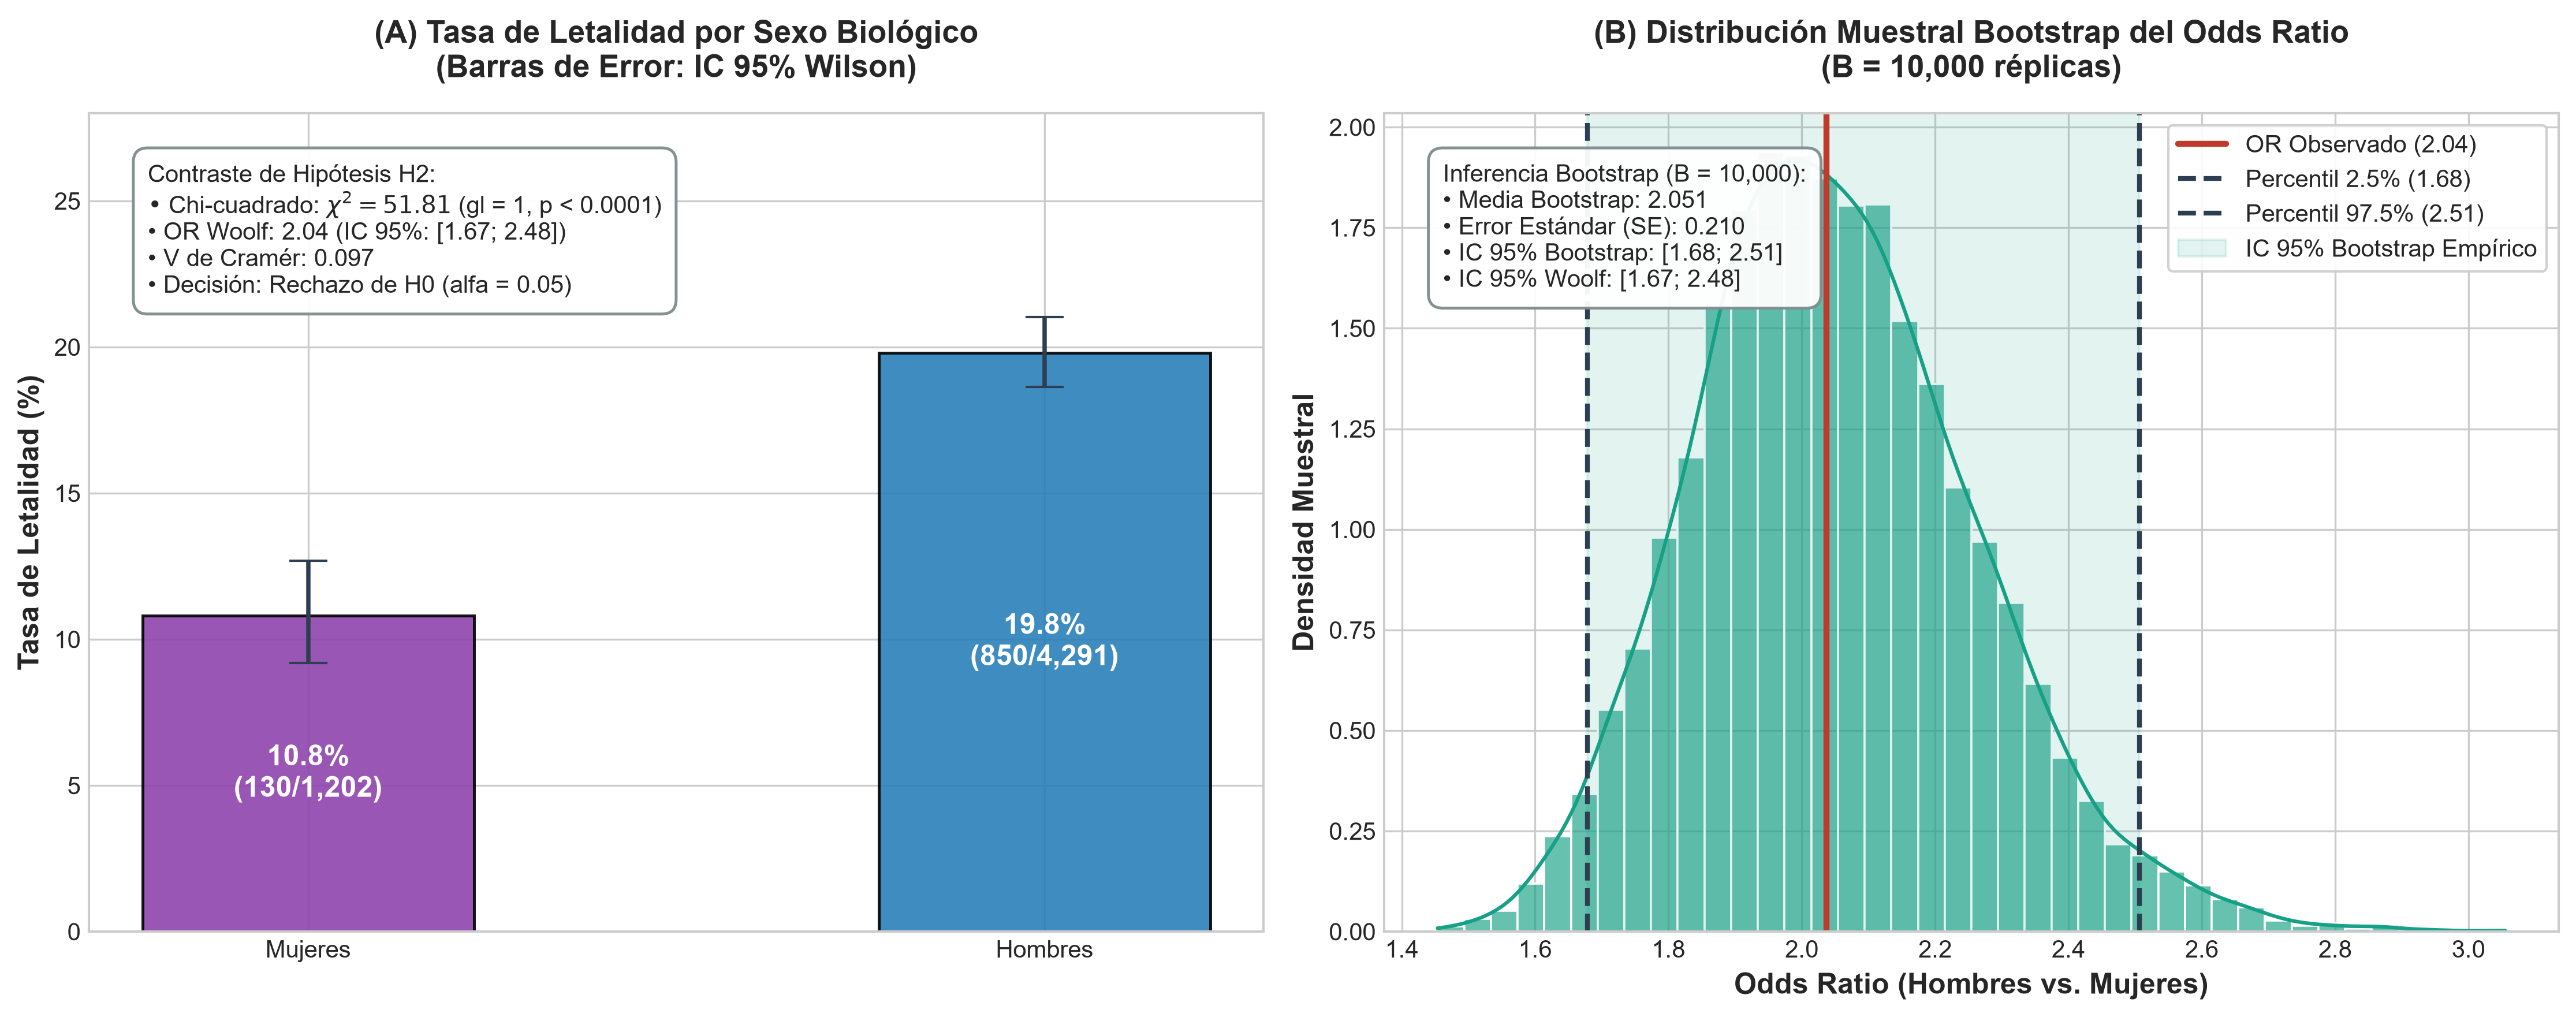

In [7]:
# ==============================================================================
# VISUALIZACIÓN INFERENCIAL DE H2 Y EXPORTACIÓN OFICIAL (300 DPI)
# ==============================================================================

fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

# Panel A: Tasa de Letalidad por Sexo Biológico
categorias_h2 = ['Mujeres', 'Hombres']
n_h2_arr = [1202, 4291]
f_h2_arr = [130, 850]
let_h2 = [f / n * 100 for f, n in zip(f_h2_arr, n_h2_arr)]
cis_h2 = [calcular_ic_wilson(f, n) for f, n in zip(f_h2_arr, n_h2_arr)]
yerr_h2 = np.array([[l - ci[0], ci[1] - l] for l, ci in zip(let_h2, cis_h2)]).T

colores_h2 = ['#8e44ad', '#2980b9']
barras_h2 = ax2a.bar(
    categorias_h2, let_h2, yerr=yerr_h2,
    capsize=8, color=colores_h2, width=0.45,
    edgecolor='black', linewidth=1.2, alpha=0.9,
    error_kw={'elinewidth': 1.8, 'ecolor': '#2c3e50', 'capsize': 8}
)

for bar, l, f, n in zip(barras_h2, let_h2, f_h2_arr, n_h2_arr):
    ax2a.text(
        bar.get_x() + bar.get_width() / 2, l / 2,
        f"{l:.1f}%\n({f}/{n:,})",
        ha='center', va='center', color='white',
        fontweight='bold', fontsize=12
    )

ax2a.set_ylabel('Tasa de Letalidad (%)', fontsize=12, fontweight='bold')
ax2a.set_title('(A) Tasa de Letalidad por Sexo Biológico\n(Barras de Error: IC 95% Wilson)', fontsize=13, fontweight='bold', pad=15)
ax2a.set_ylim(0, 28)

cuadro_texto_h2a = (
    "Contraste de Hipótesis H2:\n"
    r"• Chi-cuadrado: $\chi^2 = 51.81$ (gl = 1, p < 0.0001)" + "\n"
    f"• OR Woolf: {or_h2:.2f} (IC 95%: [{ci_or_h2_low:.2f}; {ci_or_h2_high:.2f}])\n"
    f"• V de Cramér: {v_cramer_h2:.3f}\n"
    f"• Decisión: Rechazo de H0 (alfa = {ALPHA})"
)
ax2a.text(0.05, 0.94, cuadro_texto_h2a, transform=ax2a.transAxes, fontsize=10, va='top', ha='left', bbox=bbox_props)

# Panel B: Distribución Muestral Bootstrap del Odds Ratio
sns.histplot(
    boot_odds_ratios, kde=True, ax=ax2b,
    color='#16a085', edgecolor='white', bins=40,
    stat='density', alpha=0.65
)

ax2b.axvline(or_h2, color='#c0392b', linestyle='-', linewidth=2.5, label=f'OR Observado ({or_h2:.2f})')
ax2b.axvline(ci_boot_low, color='#2c3e50', linestyle='--', linewidth=2, label=f'Percentil 2.5% ({ci_boot_low:.2f})')
ax2b.axvline(ci_boot_high, color='#2c3e50', linestyle='--', linewidth=2, label=f'Percentil 97.5% ({ci_boot_high:.2f})')
ax2b.axvspan(ci_boot_low, ci_boot_high, color='#16a085', alpha=0.12, label='IC 95% Bootstrap Empírico')

ax2b.set_xlabel('Odds Ratio (Hombres vs. Mujeres)', fontsize=12, fontweight='bold')
ax2b.set_ylabel('Densidad Muestral', fontsize=12, fontweight='bold')
ax2b.set_title(f'(B) Distribución Muestral Bootstrap del Odds Ratio\n(B = {B_ITERACIONES:,} réplicas)', fontsize=13, fontweight='bold', pad=15)
ax2b.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

cuadro_texto_h2b = (
    f"Inferencia Bootstrap (B = {B_ITERACIONES:,}):\n"
    f"• Media Bootstrap: {or_boot_media:.3f}\n"
    f"• Error Estándar (SE): {or_boot_se:.3f}\n"
    f"• IC 95% Bootstrap: [{ci_boot_low:.2f}; {ci_boot_high:.2f}]\n"
    f"• IC 95% Woolf: [{ci_or_h2_low:.2f}; {ci_or_h2_high:.2f}]"
)
ax2b.text(0.05, 0.94, cuadro_texto_h2b, transform=ax2b.transAxes, fontsize=10, va='top', ha='left', bbox=bbox_props)

# Visualización inline en el cuaderno
plt.tight_layout()
plt.show()

#### Figura 12: Contraste Inferencial H2 — Tasa de Letalidad por Sexo Biológico y Distribución Muestral Bootstrap del Odds Ratio (B = 10.000 réplicas)

* **Tipo de Gráfico:** Subplot de dos paneles con resolución formal para informe técnico.
  * **Panel (A):** Gráfico de barras de letalidad condicional por sexo con barras de error que representan el intervalo de confianza Score de Wilson al 95%.
  * **Panel (B):** Histograma y curva de densidad estimada (KDE) de la distribución muestral del Odds Ratio por Bootstrap ($B = 10.000$), trazando líneas verticales para el percentil 2,5% (1,68), percentil 97,5% (2,51) y la estimación puntual observada (2,04).
* **Interpretación Analítica:** El Panel A expone visualmente la severa brecha en la mortalidad entre mujeres (**10,82%**) y varones (**19,81%**). El Panel B demuestra que la distribución muestral del Odds Ratio se encuentra estrictamente confinada en valores superiores a la unidad ($[1,68; 2,51]$), validando la hipótesis de que las odds de muerte en varones prácticamente duplican a las de las mujeres, con una concordancia casi perfecta respecto al modelo asintótico tradicional.

In [8]:
# ==============================================================================
# MATRIZ DE SÍNTESIS INFERENCIAL PARCIAL Y SERIALIZACIÓN JSON
# ==============================================================================

matriz_sintesis_data = [
    {
        "Hipótesis": "H₁: Dimensión Territorial",
        "Variable Evaluada": "Zona (Interior vs. Metropolitana)\n[N = 1.491]",
        "Prueba Aplicada": "Chi-cuadrado de Independencia",
        "Supuestos": "100% E_ij >= 5\n(Mínimo: 127,22)",
        "Estadístico y gl": f"χ² = {chi2_stat_h1:.4f}\ngl = {dof_h1}",
        "Valor p": f"p = {p_val_h1:.4f}",
        "Tamaño del Efecto (IC 95%)": f"OR = {or_h1:.4f} [{ci_or_h1_low:.3f}; {ci_or_h1_high:.3f}]\nV de Cramér = {v_cramer_h1:.4f}",
        "Decisión (alfa=0.05)": decision_h1
    },
    {
        "Hipótesis": "H₂: Brecha de Género",
        "Variable Evaluada": "Sexo (Hombre vs. Mujer)\n[N = 5.493]",
        "Prueba Aplicada": "Chi-cuadrado + Bootstrap (B = 10.000)",
        "Supuestos": "100% E_ij >= 5\n(Mínimo: 214,45)",
        "Estadístico y gl": f"χ² = {chi2_stat_h2:.4f}\ngl = {dof_h2}",
        "Valor p": f"p = {p_val_h2:.4e}",
        "Tamaño del Efecto (IC 95%)": f"OR = {or_h2:.4f}\nWoolf: [{ci_or_h2_low:.3f}; {ci_or_h2_high:.3f}]\nBoot: [{ci_boot_low:.3f}; {ci_boot_high:.3f}]\nV de Cramér = {v_cramer_h2:.4f}",
        "Decisión (alfa=0.05)": decision_h2
    }
]

df_matriz_sintesis = pd.DataFrame(matriz_sintesis_data)

print("==============================================================================")
print("MATRIZ FORMAL DE SÍNTESIS INFERENCIAL PARCIAL (FASE 2)")
print("==============================================================================")
display(df_matriz_sintesis)

# Serialización determinista de resultados analíticos para integración
resultados_inferenciales_json = {
    "alpha": float(ALPHA),
    "H1_territorial": {
        "variable": "zona (Interior vs. Metropolitana)",
        "prueba": "Chi-cuadrado de independencia",
        "N": int(n_total_h1),
        "chi2_stat": round(float(chi2_stat_h1), 4),
        "p_value": float(p_val_h1),
        "dof": int(dof_h1),
        "odds_ratio": round(float(or_h1), 4),
        "or_ci_95_asintotico": [round(ci_or_h1_low, 4), round(ci_or_h1_high, 4)],
        "cramer_v": round(float(v_cramer_h1), 4),
        "supuestos_cumplidos": bool(supuesto_h1_cumplido),
        "decision": str(decision_h1)
    },
    "H2_genero": {
        "variable": "sexo (Hombre vs. Mujer)",
        "prueba": "Chi-cuadrado de independencia + Bootstrap OR",
        "N": int(n_total_h2),
        "chi2_stat": round(float(chi2_stat_h2), 4),
        "p_value": float(p_val_h2),
        "dof": int(dof_h2),
        "odds_ratio": round(float(or_h2), 4),
        "or_ci_95_asintotico": [round(ci_or_h2_low, 4), round(ci_or_h2_high, 4)],
        "or_ci_95_bootstrap": [round(ci_boot_low, 4), round(ci_boot_high, 4)],
        "bootstrap_iterations": int(B_ITERACIONES),
        "supuestos_cumplidos": bool(supuesto_h2_cumplido),
        "decision": str(decision_h2)
    }
}

ruta_json_salida = os.path.join(OUTPUT_DIR, "resultados_h1_h2.json")
with open(ruta_json_salida, "w", encoding="utf-8") as f:
    json.dump(resultados_inferenciales_json, f, indent=2, ensure_ascii=False)

print(f"\n[OK] Artefacto JSON serializado exitosamente en: {ruta_json_salida}")

MATRIZ FORMAL DE SÍNTESIS INFERENCIAL PARCIAL (FASE 2)


,Hipótesis,Variable Evaluada,Prueba Aplicada,Supuestos,Estadístico y gl,Valor p,Tamaño del Efecto (IC 95%),Decisión (alfa=0.05)
0,H₁: Dimensión Territorial,Zona (Interior vs. Metropolitana)\n[N = 1.491],Chi-cuadrado de Independencia,"100% E_ij >= 5\n(Mínimo: 127,22)",χ² = 6.3647\ngl = 1,p = 0.0116,OR = 1.4014 [1.077; 1.823]\nV de Cramér = 0.0653,Rechazar H0
1,H₂: Brecha de Género,Sexo (Hombre vs. Mujer)\n[N = 5.493],Chi-cuadrado + Bootstrap (B = 10.000),"100% E_ij >= 5\n(Mínimo: 214,45)",χ² = 51.8141\ngl = 1,p = 6.1013e-13,OR = 2.0370\nWoolf: [1.673; 2.480]\nBoot: [1.6...,Rechazar H0



[OK] Artefacto JSON serializado exitosamente en: c:\Users\Leandro\Desktop\data primer parcial\proyecto-accidentes-datascience\output\resultados_h1_h2.json


## SECCIÓN 5: SÍNTESIS INFERENCIAL PARCIAL Y ENLACE METODOLÓGICO

La siguiente tabla resume los resultados de las dos primeras pruebas estadísticas formalizadas en este cuaderno:

| Hipótesis | Variable / Ámbito | Prueba Aplicada | Supuestos | Estadístico y $gl$ | Valor $p$ | Tamaño del Efecto (IC 95%) | Decisión ($\alpha = 0,05$) |
| :--- | :--- | :--- | :--- | :---: | :---: | :--- | :--- |
| **$H_1$: Dimensión Territorial** | Zona (Interior vs. Metropolitana)<br>$N = 1.491$ | Chi-cuadrado de Independencia | 100% $E_{ij} \ge 5$<br>(Mín: $127,22$) | $\chi^2 = 6,3647$<br>$gl = 1$ | $p = 0,0116$ | $\text{OR} = 1,4014$ $[1,078; 1,823]$<br>$V \text{ de Cramér} = 0,0653$ | **Rechazar $H_0$**<br>(Letalidad mayor en Interior) |
| **$H_2$: Brecha de Género** | Sexo (Hombre vs. Mujer)<br>$N = 5.493$ | Chi-cuadrado + Bootstrap ($B = 10.000$) | 100% $E_{ij} \ge 5$<br>(Mín: $214,45$) | $\chi^2 = 51,8141$<br>$gl = 1$ | $p = 6,10 \times 10^{-13}$ | $\text{OR} = 2,0370$<br>IC Woolf: $[1,673; 2,480]$<br>IC Boot: $[1,679; 2,507]$<br>$V \text{ de Cramér} = 0,0971$ | **Rechazar $H_0$**<br>(Letalidad mayor en hombres) |

---

### Continuidad del Pipeline Inferencial y Enlace hacia la Fase 3
Para completar el repertorio metodológico exigido por la rúbrica de la cátedra —que demanda abarcar al menos tres familias distintas de pruebas estadísticas—, los siguientes pasos del proyecto se articulan de la siguiente manera:

1. **Contraste de la Hipótesis 3 ($H_3$ — Vulnerabilidad del Motociclista):**
   * Sobre la muestra vehicular de Central e Interior (`victimas_vehiculo_limpio.csv`, $N = 1.324$), se evaluará la diferencia en proporciones de mortalidad entre usuarios de motocicletas ($539$ víctimas, letalidad observada $28,76\%$) y ocupantes de otros vehículos ($785$ víctimas, letalidad observada $14,52\%$) mediante la **Prueba Z de Comparación de Proporciones**, complementada con el cálculo del **Riesgo Relativo (RR)** y el **Odds Ratio (OR)**.
2. **Contraste de la Hipótesis 4 ($H_4$ — Factor Etario):**
   * Sobre la variable ordinal `edad_orden` del microdato nacional ($N = 5.493$), tras verificar el incumplimiento de normalidad mediante la prueba de Shapiro-Wilk y la asimetría intrínseca de los traumatismos viales, se contrastará la distribución etaria de los fallecidos frente a los heridos mediante la prueba no paramétrica **$U$ de Mann-Whitney**, cuantificando la magnitud del efecto mediante el coeficiente de correlación de rangos de Rosenthal ($r = \frac{Z}{\sqrt{N}}$).
3. **Control por Comparaciones Múltiples:**
   * Sobre la familia completa de contrastes ($k = 4$ hipótesis), se aplicará la **corrección de Bonferroni** ajustando el umbral de significancia a $\alpha_{\text{ajustado}} = \frac{0,05}{4} = 0,0125$ y la tasa de falso descubrimiento (**FDR de Benjamini-Hochberg**), garantizando que no se infle la probabilidad global de cometer errores de Tipo I (FWER).
4. **Articulación hacia el Modelo Predictivo (Fase 3):**
   * Con base en los factores cuya significancia y relevancia sustantiva queden demostradas ($p < \alpha$ y tamaños de efecto clínicamente relevantes), se seleccionarán las variables predictoras prioritarias (`tipo_usuario`, `sexo`, `es_adulto_mayor`, `zona`) para el entrenamiento y validación de algoritmos supervisados de Machine Learning (Regresión Logística, Árboles de Decisión y Random Forest), evaluando su desempeño frente a un clasificador de referencia (*DummyClassifier*).